# **AI Powered Waste Classification and recycling suggestion system**

# Downloading Dataset

In [ ]:
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("mostafaabla/garbage-classification")
data_path = os.path.join(path, "garbage_classification")

print(os.listdir(data_path))

Using Colab cache for faster access to the 'garbage-classification' dataset.
['metal', 'white-glass', 'biological', 'paper', 'brown-glass', 'battery', 'trash', 'cardboard', 'shoes', 'clothes', 'plastic', 'green-glass']


# Exploratory analysis of Data

In [ ]:
for cls in sorted(os.listdir(data_path)):
    cls_dir = os.path.join(data_path, cls)
    count = len(os.listdir(cls_dir))
    print(f"{cls:<15} {count} images")

battery         945 images
biological      985 images
brown-glass     607 images
cardboard       891 images
clothes         5325 images
green-glass     629 images
metal           769 images
paper           1050 images
plastic         865 images
shoes           1977 images
trash           697 images
white-glass     775 images


# Remaping all 12 classes into 8, caps textile at 1500 and saves everything to a new folder

In [ ]:
import os
import shutil
import random
from pathlib import Path

random.seed(42)

# Final class mapping
CLASS_MAP = {
    "white-glass"  : "glass",
    "brown-glass"  : "glass",
    "green-glass"  : "glass",
    "biological"   : "organic",
    "paper"        : "paper",
    "cardboard"    : "paper",
    "plastic"      : "plastic",
    "metal"        : "metal",
    "battery"      : "hazardous",
    "clothes"      : "textile",
    "shoes"        : "textile",
    "trash"        : "general",
}

TEXTILE_CAP = 1500
output_path  = Path("/content/waste_dataset")
output_path.mkdir(exist_ok=True)

# Copy images
for original_cls, new_cls in CLASS_MAP.items():
    src_dir = Path(data_path) / original_cls
    dst_dir = output_path / new_cls
    dst_dir.mkdir(exist_ok=True)

    images = [f for f in os.listdir(src_dir)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Cap textile
    if new_cls == "textile":
        images = random.sample(images, min(TEXTILE_CAP, len(images)))

    for fname in images:
        new_name = f"{original_cls}_{fname}"
        shutil.copy(src_dir / fname, dst_dir / new_name)

# Summary
print("Final class counts:")
print("-" * 30)
total = 0
for cls_dir in sorted(output_path.iterdir()):
    count = len(os.listdir(cls_dir))
    total += count
    print(f"  {cls_dir.name:<12} {count} images")
print(f"\n  Total: {total} images")

Final class counts:
------------------------------
  general      697 images
  glass        2011 images
  hazardous    945 images
  metal        769 images
  organic      985 images
  paper        1941 images
  plastic      865 images
  textile      3000 images

  Total: 11213 images


In [ ]:
# Fix textile cap
import random
random.seed(42)

textile_dir = Path("/content/waste_dataset/textile")
all_textile = os.listdir(textile_dir)

print(f"Current textile count: {len(all_textile)}")

# Keep only 1500 randomly
to_delete = random.sample(all_textile, len(all_textile) - 1500)
for fname in to_delete:
    os.remove(textile_dir / fname)

print(f"After cap: {len(os.listdir(textile_dir))} images")

Current textile count: 3000
After cap: 1500 images


In [ ]:
print("Final class counts:")
print("-" * 30)
total = 0
for cls_dir in sorted(Path("/content/waste_dataset").iterdir()):
    count = len(os.listdir(cls_dir))
    total += count
    print(f"  {cls_dir.name:<12} {count} images")
print(f"\n  Total: {total} images")

Final class counts:
------------------------------
  general      697 images
  glass        2011 images
  hazardous    945 images
  metal        769 images
  organic      985 images
  paper        1941 images
  plastic      865 images
  textile      1500 images

  Total: 9713 images


# Saving data to google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil

drive_path = "/content/drive/MyDrive/waste_fyp"

print("Copying dataset to Drive... this will take 2-3 minutes")
shutil.copytree("/content/waste_dataset", f"{drive_path}/waste_dataset")
print("Done! Dataset saved to Google Drive.")

Copying dataset to Drive... this will take 2-3 minutes
Done! Dataset saved to Google Drive.


# train/val/test split

In [ ]:
import os
import shutil
import random
from pathlib import Path

random.seed(42)

source      = Path("/content/waste_dataset")
destination = Path("/content/waste_split")

TRAIN = 0.70
VAL   = 0.15
TEST  = 0.15

for cls_dir in sorted(source.iterdir()):
    if not cls_dir.is_dir():
        continue

    images = [f for f in os.listdir(cls_dir)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)

    n       = len(images)
    n_train = int(n * TRAIN)
    n_val   = int(n * VAL)

    splits = {
        "train" : images[:n_train],
        "val"   : images[n_train : n_train + n_val],
        "test"  : images[n_train + n_val:],
    }

    for split_name, split_files in splits.items():
        split_dir = destination / split_name / cls_dir.name
        split_dir.mkdir(parents=True, exist_ok=True)
        for fname in split_files:
            shutil.copy(cls_dir / fname, split_dir / fname)

# Verify
print("Split summary:")
print("-" * 40)
for split in ["train", "val", "test"]:
    split_total = 0
    print(f"\n  {split.upper()}")
    for cls_dir in sorted((destination / split).iterdir()):
        count = len(os.listdir(cls_dir))
        split_total += count
        print(f"    {cls_dir.name:<12} {count} images")
    print(f"    {'TOTAL':<12} {split_total} images")

Split summary:
----------------------------------------

  TRAIN
    general      487 images
    glass        1407 images
    hazardous    661 images
    metal        538 images
    organic      689 images
    paper        1358 images
    plastic      605 images
    textile      1050 images
    TOTAL        6795 images

  VAL
    general      104 images
    glass        301 images
    hazardous    141 images
    metal        115 images
    organic      147 images
    paper        291 images
    plastic      129 images
    textile      225 images
    TOTAL        1453 images

  TEST
    general      106 images
    glass        303 images
    hazardous    143 images
    metal        116 images
    organic      149 images
    paper        292 images
    plastic      131 images
    textile      225 images
    TOTAL        1465 images


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

# Config
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 8
AUTOTUNE    = tf.data.AUTOTUNE

data_dir    = "/content/waste_split"
CLASS_NAMES = sorted(os.listdir(f"{data_dir}/train"))

print("Classes:", CLASS_NAMES)
print("Number of classes:", len(CLASS_NAMES))

Classes: ['general', 'glass', 'hazardous', 'metal', 'organic', 'paper', 'plastic', 'textile']
Number of classes: 8


# Full data pipeline with augmentation

In [ ]:
# Augmentation (only applied to training)
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
], name="augmentation")


# Dataset loader
def load_dataset(split):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory   = f"{data_dir}/{split}",
        image_size  = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        label_mode  = "categorical",
        class_names = CLASS_NAMES,
        shuffle     = (split == "train"),
        seed        = 42,
    )
    return ds


# Load all splits
train_ds = load_dataset("train")
val_ds   = load_dataset("val")
test_ds  = load_dataset("test")


# Apply augmentation + prefetch
train_ds = (train_ds
            .map(lambda x, y: (augmentation(x, training=True), y),
                 num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))

val_ds  = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


# Verify
for images, labels in train_ds.take(1):
    print(f"Image batch shape : {images.shape}")
    print(f"Label batch shape : {labels.shape}")
    print(f"Pixel range       : min={images.numpy().min():.1f}  max={images.numpy().max():.1f}")


Found 6795 files belonging to 8 classes.
Found 1453 files belonging to 8 classes.
Found 1465 files belonging to 8 classes.
Image batch shape : (32, 224, 224, 3)
Label batch shape : (32, 8)
Pixel range       : min=0.0  max=255.0


# EfficientNetB0 with transfer learning

In [ ]:
# Base model
base_model = EfficientNetB0(
    include_top = False,
    weights     = "imagenet",
    input_shape = (224, 224, 3)
)

# Freeze base first — we only train the head initially
base_model.trainable = False

# Build full model
inputs  = layers.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation="relu")(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

# Compile
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,683 (16.73 MB)

 Trainable params: 332,552 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

# Training Phase 1 — just the head, backbone frozen

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint(
        filepath    = "/content/best_model.keras",
        monitor     = "val_accuracy",
        save_best_only = True,
        verbose     = 1
    ),
    EarlyStopping(
        monitor  = "val_accuracy",
        patience = 5,
        verbose  = 1,
        restore_best_weights = True
    ),
    ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.3,
        patience = 3,
        verbose  = 1
    ),
]

# Phase 1 — train head only
print("Phase 1: Training head only...")

history_phase1 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = 10,
    callbacks       = callbacks,
)

Phase 1: Training head only...
Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.7314 - loss: 0.8782
Epoch 1: val_accuracy improved from None to 0.93255, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 146s 532ms/step - accuracy: 0.8206 - loss: 0.5786 - val_accuracy: 0.9326 - val_loss: 0.2111 - learning_rate: 0.0010
Epoch 2/10
212/213 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.8909 - loss: 0.3208
Epoch 2: val_accuracy improved from 0.93255 to 0.93806, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 77s 362ms/step - accuracy: 0.8917 - loss: 0.3212 - val_accuracy: 0.9381 - val_loss: 0.2004 - learning_rate: 0.0010
Epoch 3/10
212/213 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9139 - loss: 0.2554
Epoch 3: val_accuracy improved from 0.93806 to 0.94081, saving model to /content/best_model.keras

Ep

# Now Phase 2 — we unfreeze the top layers of EfficientNetB0 and fine-tune with a very low learning rate.

In [ ]:
# Phase 2 — unfreeze top 30 layers and fine-tune
base_model.trainable = True

# Freeze all except last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Trainable layers: {sum([l.trainable for l in base_model.layers])}")

# Recompile with much lower learning rate
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)

print("Phase 2: Fine-tuning top layers...")

history_phase2 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = 10,
    callbacks       = callbacks,
)

Trainable layers: 30
Phase 2: Fine-tuning top layers...
Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.8839 - loss: 0.3515
Epoch 1: val_accuracy did not improve from 0.96008
213/213 ━━━━━━━━━━━━━━━━━━━━ 133s 478ms/step - accuracy: 0.8907 - loss: 0.3357 - val_accuracy: 0.9353 - val_loss: 0.2074 - learning_rate: 1.0000e-05
Epoch 2/10
212/213 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.8959 - loss: 0.2984
Epoch 2: val_accuracy did not improve from 0.96008
213/213 ━━━━━━━━━━━━━━━━━━━━ 77s 358ms/step - accuracy: 0.9007 - loss: 0.2860 - val_accuracy: 0.9319 - val_loss: 0.2108 - learning_rate: 1.0000e-05
Epoch 3/10
212/213 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.9195 - loss: 0.2586
Epoch 3: val_accuracy did not improve from 0.96008

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
213/213 ━━━━━━━━━━━━━━━━━━━━ 81s 356ms/step - accuracy: 0.9145 - loss: 0.2647 - val_accuracy: 0.9374 - val_loss: 0.2007 - learning_rate: 1.0000e-05
Epoc

# Reload the best model and evaluate

In [ ]:
# Load the best model from Phase 1
model = tf.keras.models.load_model("/content/best_model.keras")

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 24s 305ms/step - accuracy: 0.9652 - loss: 0.1223

Test Accuracy: 96.52%
Test Loss:     0.1223


# Accuracy & Loss curves

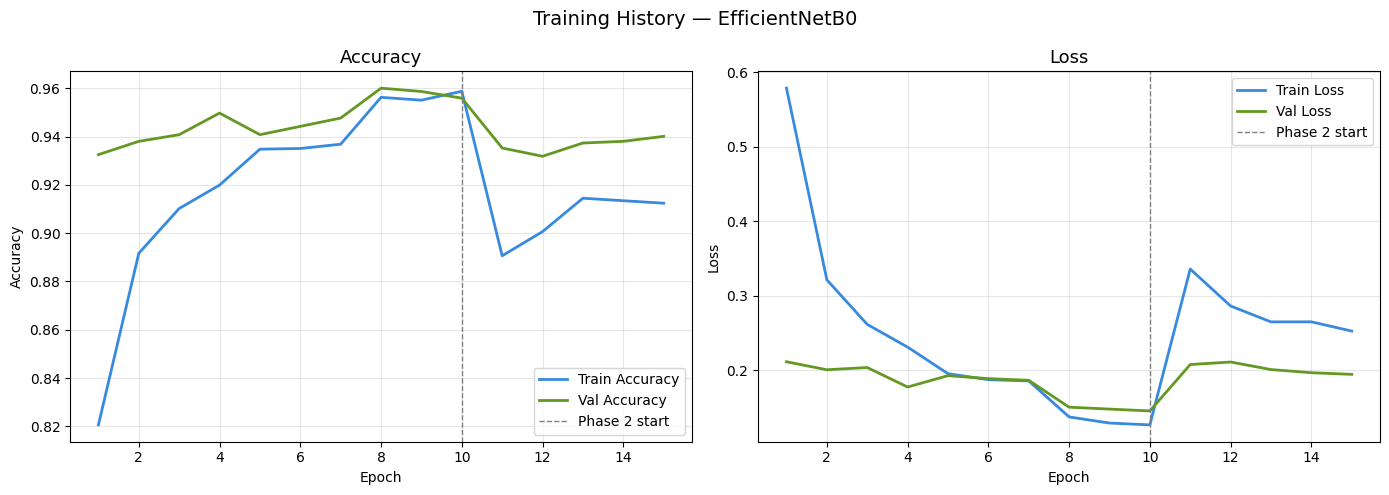

In [ ]:
import matplotlib.pyplot as plt

# Combine both phases
acc      = history_phase1.history["accuracy"] + history_phase2.history["accuracy"]
val_acc  = history_phase1.history["val_accuracy"] + history_phase2.history["val_accuracy"]
loss     = history_phase1.history["loss"] + history_phase2.history["loss"]
val_loss = history_phase1.history["val_loss"] + history_phase2.history["val_loss"]
epochs   = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(epochs, acc,     label="Train Accuracy",  color="#378ADD", linewidth=2)
axes[0].plot(epochs, val_acc, label="Val Accuracy",    color="#639922", linewidth=2)
axes[0].axvline(x=10, color="gray", linestyle="--", linewidth=1, label="Phase 2 start")
axes[0].set_title("Accuracy", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(epochs, loss,     label="Train Loss", color="#378ADD", linewidth=2)
axes[1].plot(epochs, val_loss, label="Val Loss",   color="#639922", linewidth=2)
axes[1].axvline(x=10, color="gray", linestyle="--", linewidth=1, label="Phase 2 start")
axes[1].set_title("Loss", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Training History — EfficientNetB0", fontsize=14)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/waste_fyp/training_curves.png", dpi=150)
plt.show()

# Confusion Matrix

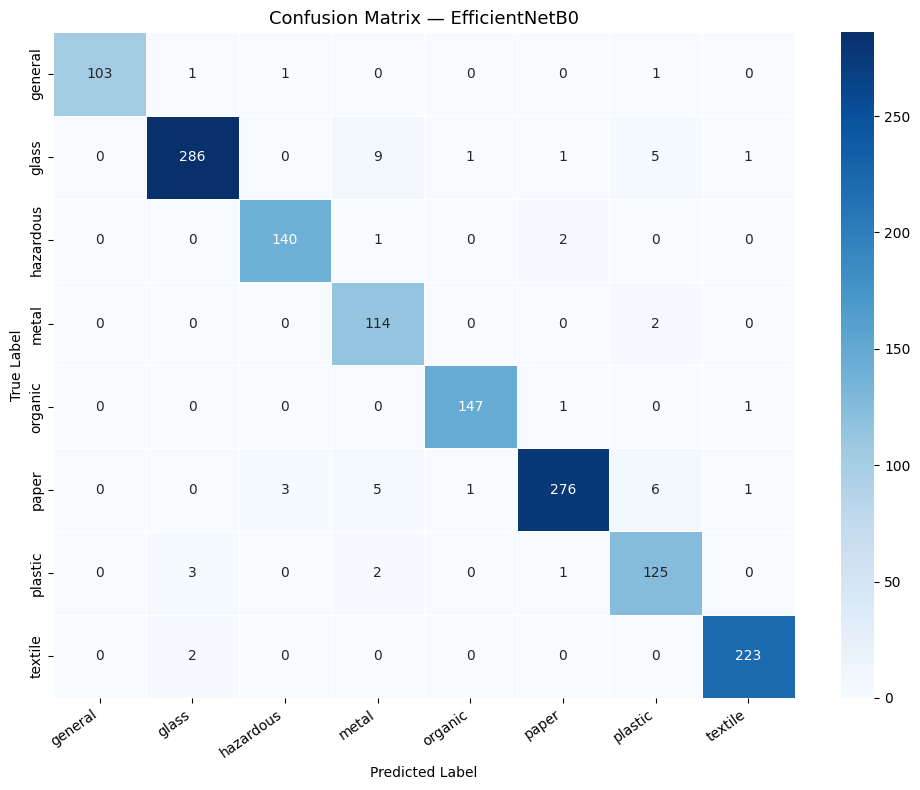

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get predictions
y_true, y_pred = [], []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot      = True,
    fmt        = "d",
    cmap       = "Blues",
    xticklabels = CLASS_NAMES,
    yticklabels = CLASS_NAMES,
    linewidths  = 0.5
)
plt.title("Confusion Matrix — EfficientNetB0", fontsize=13)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/waste_fyp/confusion_matrix.png", dpi=150)
plt.show()

# Classification Report

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true, y_pred,
    target_names = CLASS_NAMES,
    digits       = 4
)

print("Classification Report")
print("=" * 60)
print(report)

Classification Report
              precision    recall  f1-score   support

     general     1.0000    0.9717    0.9856       106
       glass     0.9795    0.9439    0.9613       303
   hazardous     0.9722    0.9790    0.9756       143
       metal     0.8702    0.9828    0.9231       116
     organic     0.9866    0.9866    0.9866       149
       paper     0.9822    0.9452    0.9634       292
     plastic     0.8993    0.9542    0.9259       131
     textile     0.9867    0.9911    0.9889       225

    accuracy                         0.9652      1465
   macro avg     0.9596    0.9693    0.9638      1465
weighted avg     0.9668    0.9652    0.9655      1465



# Saving best model to Drive

In [ ]:
model.save("/content/drive/MyDrive/waste_fyp/best_model.keras")
print("Model saved to Drive.")

Model saved to Drive.


# Metadata table

In [ ]:
# Metadata for each class
METADATA = {
    "general"  : {
        "biodegradable" : False,
        "reusable"      : False,
        "recyclable"    : False,
        "disposal"      : "Dispose in general waste bin. Try to reduce this type of waste."
    },
    "glass"    : {
        "biodegradable" : False,
        "reusable"      : True,
        "recyclable"    : True,
        "disposal"      : "Rinse and place in glass recycling bin. Handle with care."
    },
    "hazardous": {
        "biodegradable" : False,
        "reusable"      : False,
        "recyclable"    : True,
        "disposal"      : "Drop it at an e-waste or hazardous waste collection point safely."
    },
    "metal"    : {
        "biodegradable" : False,
        "reusable"      : True,
        "recyclable"    : True,
        "disposal"      : "Take it to a metal scrap or recycling center."
    },
    "organic"  : {
        "biodegradable" : True,
        "reusable"      : False,
        "recyclable"    : False,
        "disposal"      : "Compost it or put it in the biodegradable waste bin."
    },
    "paper"    : {
        "biodegradable" : True,
        "reusable"      : True,
        "recyclable"    : True,
        "disposal"      : "Recycle or reuse it for packing or crafts. Keep it dry."
    },
    "plastic"  : {
        "biodegradable" : False,
        "reusable"      : True,
        "recyclable"    : True,
        "disposal"      : "Check the plastic type and recycle if possible. Avoid single-use."
    },
    "textile"  : {
        "biodegradable" : False,
        "reusable"      : True,
        "recyclable"    : False,
        "disposal"      : "Donate if in good condition. Otherwise drop at a textile collection bin."
    },
}

# Prediction function

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict(img_path):
    # Load and preprocess
    img       = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # (1, 224, 224, 3)

    # Predict
    predictions  = model.predict(img_array, verbose=0)
    confidence   = float(np.max(predictions)) * 100
    class_index  = int(np.argmax(predictions))
    waste_type   = CLASS_NAMES[class_index]

    # Fetch metadata
    meta = METADATA[waste_type]

    # Print result
    print("=" * 40)
    print(f"  Waste type    : {waste_type.upper()}")
    print(f"  Biodegradable : {'Yes' if meta['biodegradable'] else 'No'}")
    print(f"  Confidence    : {confidence:.2f}%")
    print(f"  Reusable      : {'Yes' if meta['reusable'] else 'No'}")
    print(f"  Recyclable    : {'Yes' if meta['recyclable'] else 'No'}")
    print(f"  Disposal      : {meta['disposal']}")
    print("=" * 40)

    return {
        "waste_type"    : waste_type,
        "biodegradable" : meta["biodegradable"],
        "confidence"    : round(confidence, 2),
        "reusable"      : meta["reusable"],
        "recyclable"    : meta["recyclable"],
        "disposal"      : meta["disposal"]
    }

# Test it with a sample image

In [ ]:
# Grab one image from test set to try
sample_dir   = f"/content/waste_split/test/plastic"
sample_image = os.path.join(sample_dir, os.listdir(sample_dir)[0])

result = predict(sample_image)

  Waste type    : PLASTIC
  Biodegradable : No
  Confidence    : 99.69%
  Reusable      : Yes
  Recyclable    : Yes
  Disposal      : Check the plastic type and recycle if possible. Avoid single-use.


# Visualizing the predictions

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing import image
from google.colab import drive

drive.mount('/content/drive')

IMG_SIZE    = (224, 224)
CLASS_NAMES = ['general', 'glass', 'hazardous', 'metal',
               'organic', 'paper', 'plastic', 'textile']

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/waste_fyp/best_model.keras"
)
print("Ready.")

Mounted at /content/drive
Ready.


In [ ]:
METADATA = {
    "general"  : {"biodegradable": False, "reusable": False, "recyclable": False, "disposal": "Dispose in general waste bin. Try to reduce this type of waste."},
    "glass"    : {"biodegradable": False, "reusable": True,  "recyclable": True,  "disposal": "Rinse and place in glass recycling bin. Handle with care."},
    "hazardous": {"biodegradable": False, "reusable": False, "recyclable": True,  "disposal": "Drop it at an e-waste or hazardous waste collection point safely."},
    "metal"    : {"biodegradable": False, "reusable": True,  "recyclable": True,  "disposal": "Take it to a metal scrap or recycling center."},
    "organic"  : {"biodegradable": True,  "reusable": False, "recyclable": False, "disposal": "Compost it or put it in the biodegradable waste bin."},
    "paper"    : {"biodegradable": True,  "reusable": True,  "recyclable": True,  "disposal": "Recycle or reuse it for packing or crafts. Keep it dry."},
    "plastic"  : {"biodegradable": False, "reusable": True,  "recyclable": True,  "disposal": "Check the plastic type and recycle if possible. Avoid single-use."},
    "textile"  : {"biodegradable": False, "reusable": True,  "recyclable": False, "disposal": "Donate if in good condition. Otherwise drop at a textile collection bin."},
}

In [ ]:
def predict_and_show(img_path):
    img       = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = np.expand_dims(image.img_to_array(img), axis=0)

    predictions = model.predict(img_array, verbose=0)
    confidence  = float(np.max(predictions)) * 100
    waste_type  = CLASS_NAMES[int(np.argmax(predictions))]
    meta        = METADATA[waste_type]
    biodeg      = "Biodegradable" if meta["biodegradable"] else "Non-Biodegradable"
    color       = "#639922" if meta["biodegradable"] else "#A32D2D"

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(mpimg.imread(img_path))
    axes[0].axis("off")
    axes[0].set_title("Input Image", fontsize=12)

    axes[1].axis("off")
    axes[1].text(
        0.05, 0.95,
        f"  Waste       : {waste_type.upper()}\n\n"
        f"  Category    : {biodeg}\n\n"
        f"  Confidence  : {confidence:.2f}%\n\n"
        f"  Reusable    : {'Yes' if meta['reusable'] else 'No'}\n\n"
        f"  Recyclable  : {'Yes' if meta['recyclable'] else 'No'}\n\n"
        f"  Disposal    : {meta['disposal']}",
        transform=axes[1].transAxes, fontsize=11,
        verticalalignment="top", family="monospace",
        bbox=dict(boxstyle="round,pad=1", facecolor="#f9f9f9",
                  edgecolor=color, linewidth=2)
    )
    axes[1].set_title("Prediction Result", fontsize=12)
    plt.suptitle("Waste Classification — EfficientNetB0", fontsize=13)
    plt.tight_layout()
    plt.show()


── GENERAL ──


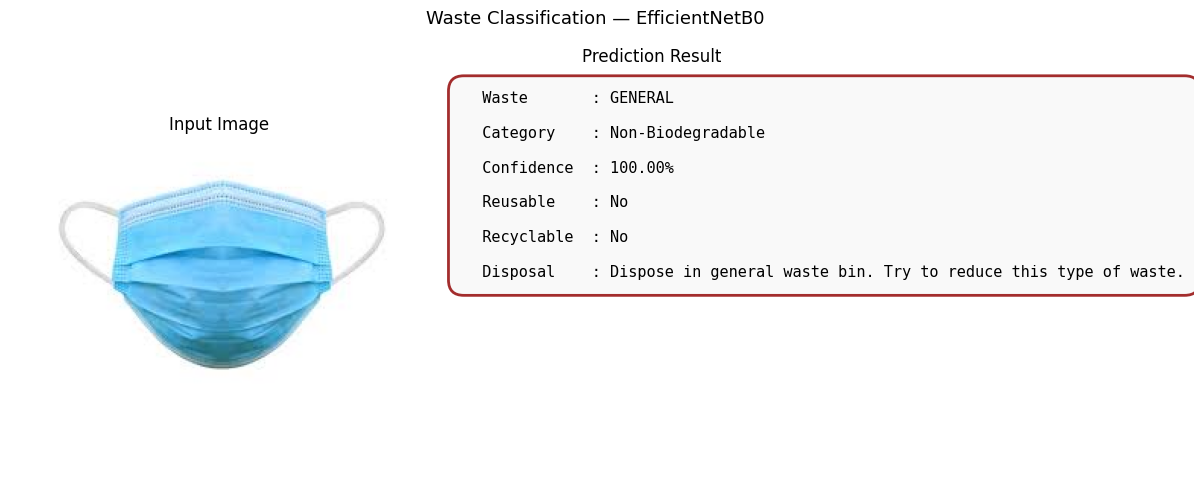


── GLASS ──


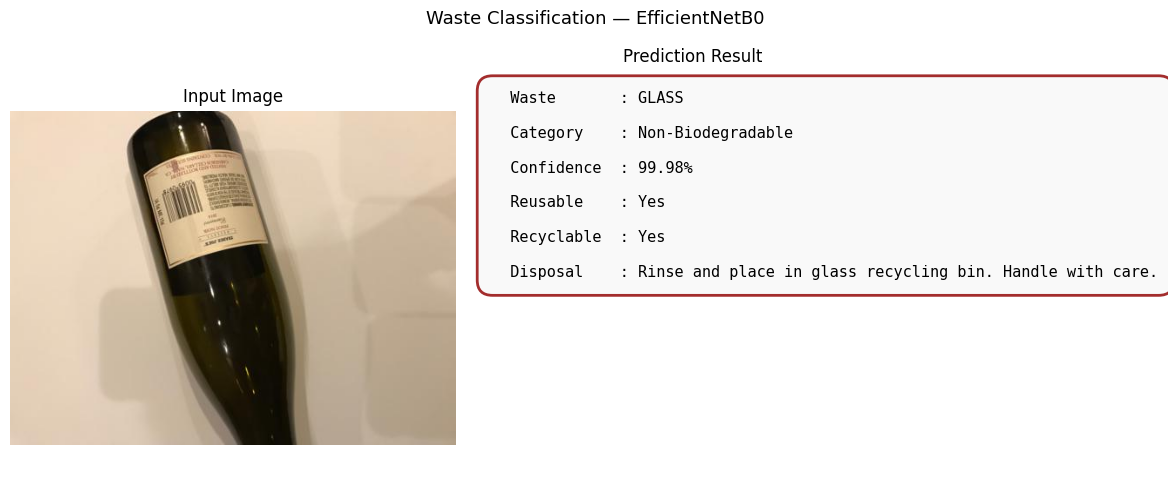


── HAZARDOUS ──


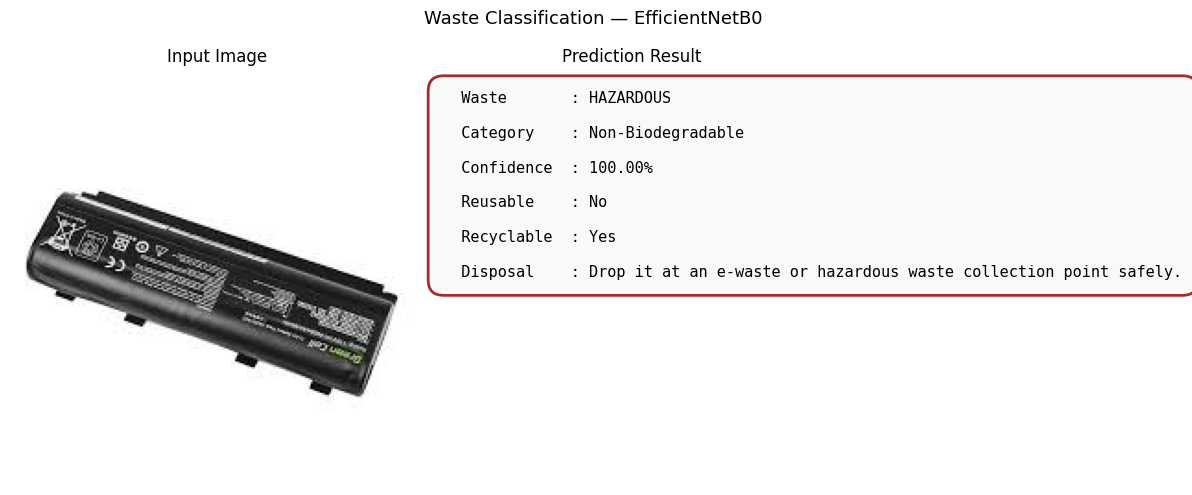


── METAL ──


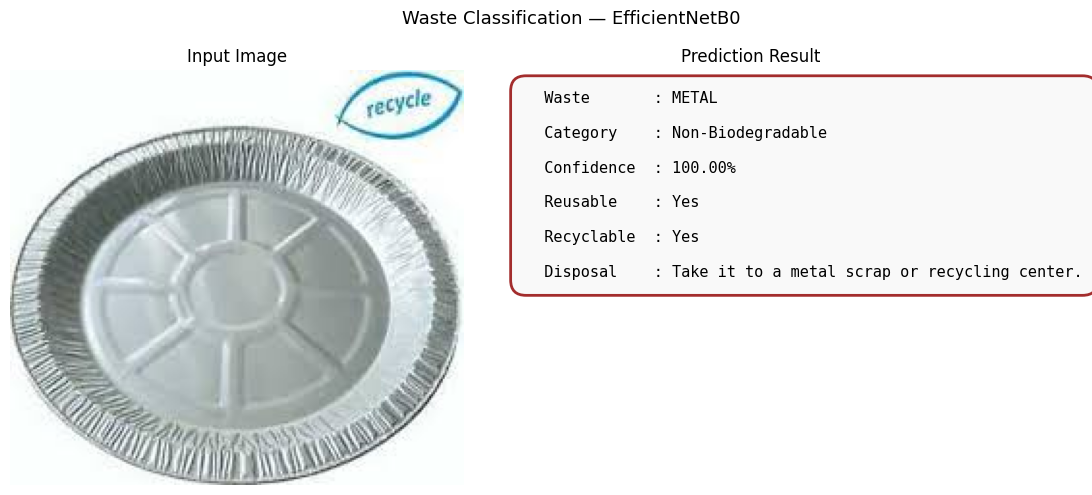


── ORGANIC ──


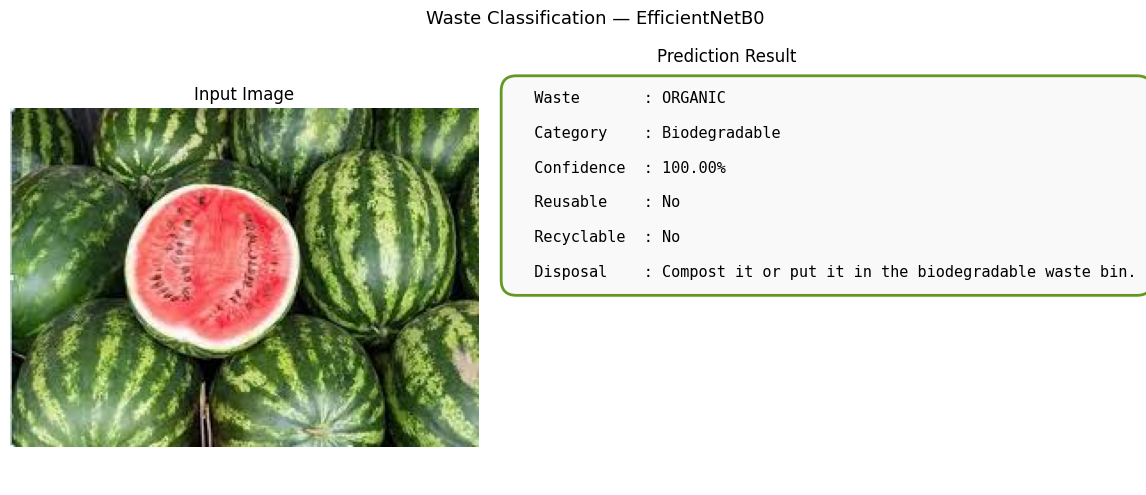


── PAPER ──


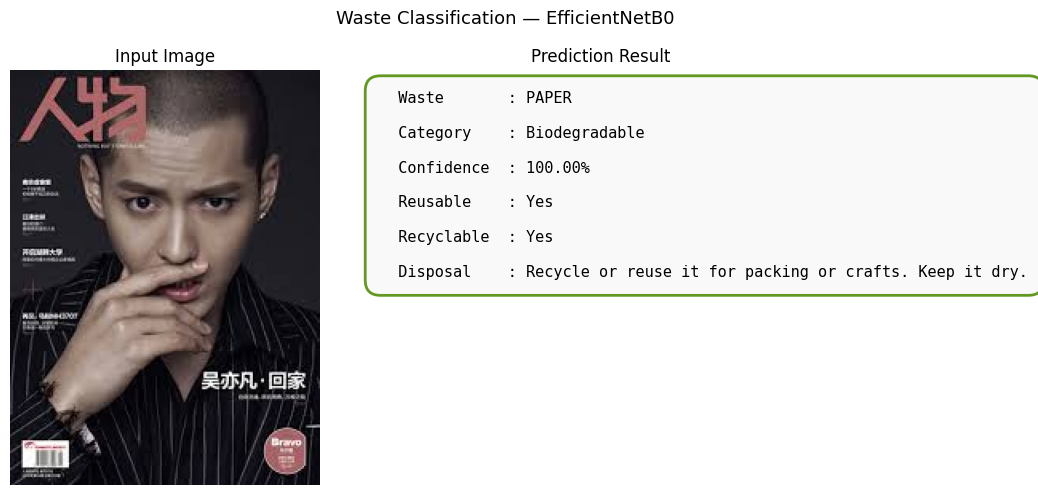


── PLASTIC ──


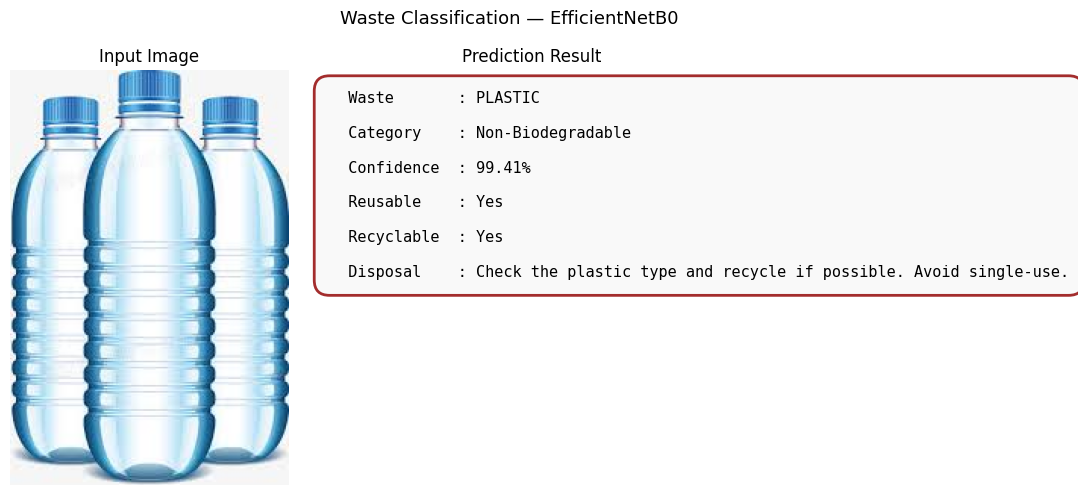


── TEXTILE ──


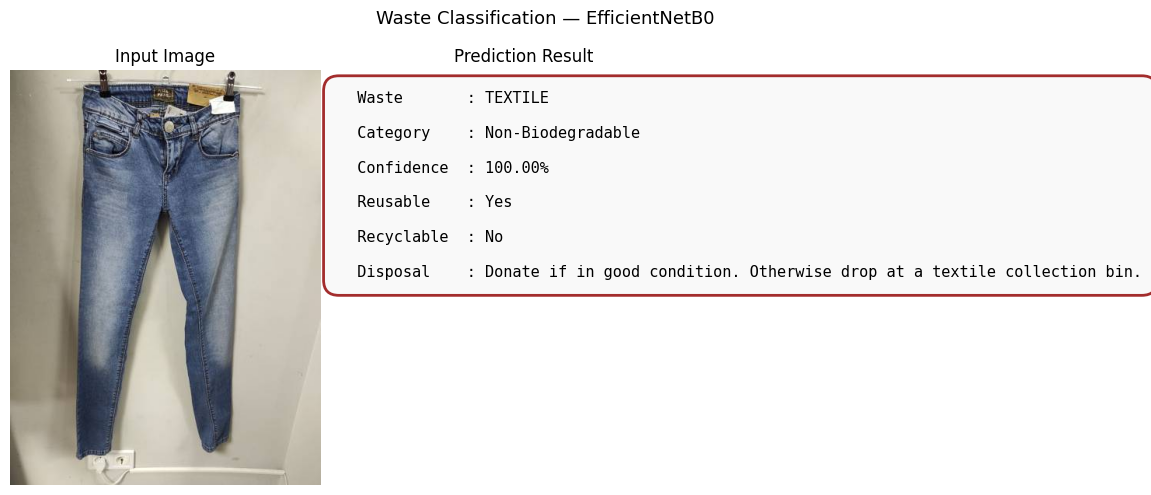

In [ ]:
base = "/content/drive/MyDrive/waste_fyp/waste_dataset"

for cls in CLASS_NAMES:
    cls_dir  = os.path.join(base, cls)
    img_path = os.path.join(cls_dir, os.listdir(cls_dir)[0])
    print(f"\n── {cls.upper()} ──")
    predict_and_show(img_path)

# Model Testing on real world self-captured images

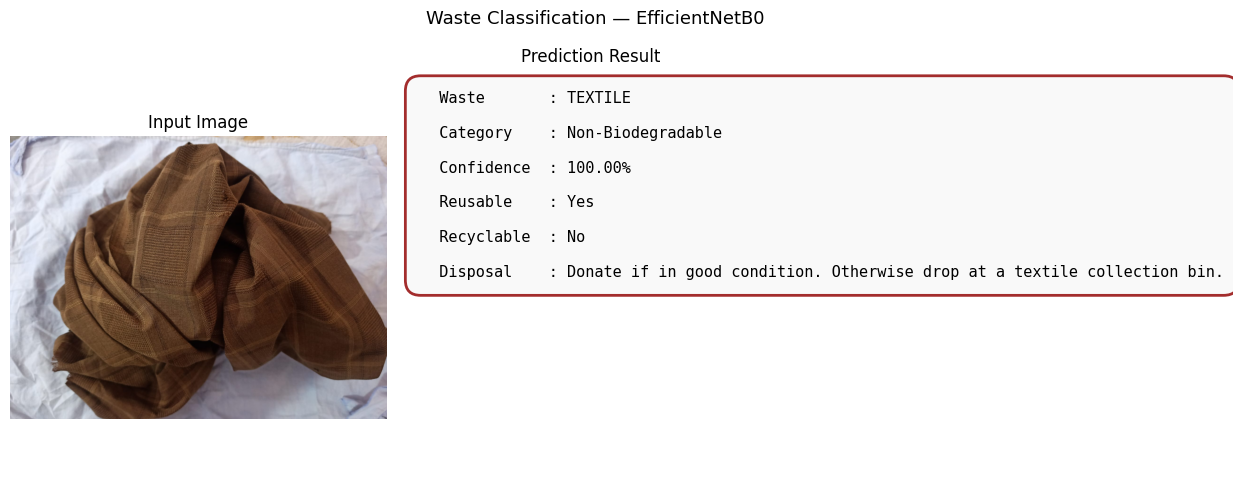

In [ ]:
predict_and_show("/content/picc.jpeg")

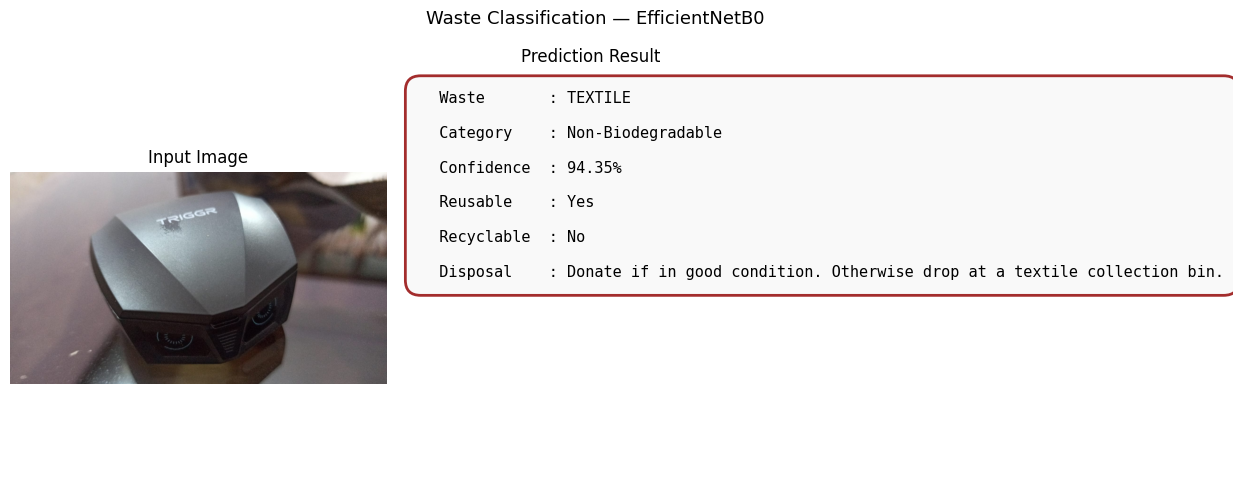

In [ ]:
predict_and_show("/content/bt.jpeg")

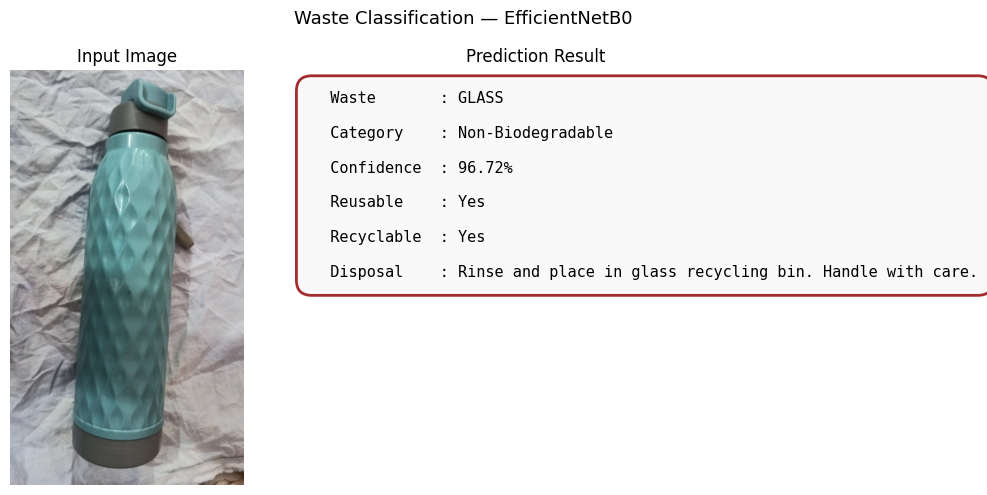

In [ ]:
predict_and_show("/content/bott.jpeg")

# **The End** - Thankyou very much